# Subtask 2 - Code Repair: Ablation Study Notebook

This notebook trains, evaluates, and compares multiple seq2seq configurations for automated code repair on the CodeXGLUE dataset.

**Ablations covered:**
| Axis | Variants |
|------|----------|
| Cell type | RNN vs GRU vs LSTM |
| Architecture | Baseline vs Attention vs Transformer |
| Depth | 1 layer vs 2 layers (LSTM) |
| Teacher forcing | 0.5 vs 1.0 vs 0.0 |
| Tokenization | Whitespace vs Character-level |

**Metrics:** Exact Match, Mean Edit Distance, BLEU, Val Loss

## 0. Setup

In [48]:
import sys, os
sys.path.insert(0, '.') # since all the .py files are in the same directory as this notebook

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda


## 1. Data

In [52]:
from data import get_dataloaders, Vocab, CharTokenizer, WhitespaceTokenizer, BPETokenizer

# dataloaders for whitespace tokenizer
train_loader_ws, val_loader_ws, test_loader_ws, vocab_ws = get_dataloaders(tokenizer=str.split, batch_size=32, max_len=150)

print(f'whitespace vocab size: {len(vocab_ws)}')

Train: 46680 | Val: 5835 | Test: 5835
Vocab size: 433
whitespace vocab size: 433


In [53]:
# dataloaders for character tokenizer
train_loader_ch, val_loader_ch, test_loader_ch, vocab_ch = get_dataloaders(tokenizer=list, batch_size=32, max_len=150)

print(f'char-level vocab size: {len(vocab_ch)}')

Train: 46680 | Val: 5835 | Test: 5835
Vocab size: 90
char-level vocab size: 90


## 2. Imports

In [4]:
# models
from baseline import Encoder as BaselineEncoder, Decoder as BaselineDecoder, Seq2Seq
from attention import AttnEncoder, AttnDecoder, AttnSeq2Seq
from transformer import TfEncoder, TfDecoder, TransformerSeq2Seq

# training
from train import train_epoch, eval_epoch

# inference
from inference import exact_match, bleu_score, mean_edit_distance

## 3. Training Utilities

In [ ]:
@torch.no_grad()
def compute_metrics(model, loader, vocab, device, n_samples=200):
    # runs inference on up to n_samples examples and returns BLEU | EM | edit dist
    model.eval()
    refs, hyps = [], []
    count = 0
    for buggy, fixed in loader:
        buggy = buggy.to(device)
        for i in range(buggy.shape[0]):
            if count >= n_samples:
                break
            ref = vocab.decode([t for t in fixed[i].tolist() if t not in (0, 1, 2)])
            hyp = vocab.decode(model.generate(buggy[i]))
            refs.append(ref)
            hyps.append(hyp)
            count += 1
        if count >= n_samples:
            break
    return {
        'bleu': bleu_score(refs, hyps),
        'exact_match': exact_match(refs, hyps),
        'mean_edit_dist': round(mean_edit_distance(refs, hyps), 2),
    }

def run_experiment(name, model, train_loader, val_loader, test_loader, vocab,
                   n_epochs=10, lr=1e-3, clip=1.0, tf_ratio=0.5, device=DEVICE):
    # training loop for one experiment, returns history + final metrics
    os.makedirs('checkpoints', exist_ok=True)

    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = float('inf')
    history = []

    for epoch in range(1, n_epochs + 1):
        tr_loss = train_epoch(model, train_loader, optimizer, criterion, clip, device)
        va_loss = eval_epoch(model, val_loader, criterion, device)
        history.append({'epoch': epoch, 'train_loss': tr_loss, 'val_loss': va_loss})
        print(f'  [{name}] epoch {epoch}/{n_epochs} | train {tr_loss:.4f} | val {va_loss:.4f}')
        if va_loss < best_val:
            best_val = va_loss
            torch.save(model.state_dict(), f'checkpoints/{name}_best.pt')

    # restore best weights
    model.load_state_dict(torch.load(f'checkpoints/{name}_best.pt', map_location=device))
    metrics = compute_metrics(model, test_loader, vocab, device)
    metrics['best_val_loss'] = round(best_val, 4)
    metrics['name'] = name
    print(f'  [{name}] BLEU={metrics["bleu"]:.4f} | EM={metrics["exact_match"]:.4f} | EditDist={metrics["mean_edit_dist"]}')
    return history, metrics


ALL_RESULTS = [] # collect metrics from every experiment
ALL_HISTORY = {} # collect loss curves

## 4. Ablation A - Cell Type: RNN vs GRU vs LSTM

**Question:** Do gated cells (GRU/LSTM) help over a vanilla RNN for this task?  
**Why it matters:** When code sequences are long, vanishing gradients in plain RNNs can prevent the encoder from capturing long-range structure.

In [ ]:
enc_a = AttnEncoder(V, embed_dim=128, hidden_dim=256, num_layers=1, model='lstm').to(DEVICE)
dec_a = AttnDecoder(V, embed_dim=128, hidden_dim=256, num_layers=1, model='lstm').to(DEVICE)
attn_model = AttnSeq2Seq(enc_a, dec_a, DEVICE).to(DEVICE)

In [ ]:
EPOCHS = 10
V = len(vocab_ws)

for cell in ['rnn', 'gru', 'lstm']:
    print(f'\n=== Cell: {cell.upper()} ===')
    enc = BaselineEncoder(V, embed_dim=128, hidden_dim=256, num_layers=1, model=cell).to(DEVICE)
    dec = BaselineDecoder(V, embed_dim=128, hidden_dim=256, num_layers=1, model=cell).to(DEVICE)
    model = Seq2Seq(enc, dec, DEVICE).to(DEVICE)
    print(f'  params: {sum(p.numel() for p in model.parameters()):,}')

    hist, metrics = run_experiment(
        name=f'baseline_{cell}', model=model,
        train_loader=train_loader_ws, val_loader=val_loader_ws, test_loader=test_loader_ws,
        vocab=vocab_ws, n_epochs=EPOCHS,
    )
    ALL_HISTORY[f'baseline_{cell}'] = hist
    ALL_RESULTS.append(metrics)


=== Cell: RNN ===
  params: 419,761
  [baseline_rnn] epoch 1/10 | train 2.2853 | val 3.5724
  [baseline_rnn] epoch 2/10 | train 2.0991 | val 3.4467
  [baseline_rnn] epoch 3/10 | train 2.0618 | val 3.4322
  [baseline_rnn] epoch 4/10 | train 2.0317 | val 3.4572
  [baseline_rnn] epoch 5/10 | train 2.0180 | val 3.5223
  [baseline_rnn] epoch 6/10 | train 2.0070 | val 3.7035
  [baseline_rnn] epoch 7/10 | train 1.9940 | val 3.5765
  [baseline_rnn] epoch 8/10 | train 1.9873 | val 3.3422
  [baseline_rnn] epoch 9/10 | train 1.9823 | val 3.5409
  [baseline_rnn] epoch 10/10 | train 1.9838 | val 3.3868
  [baseline_rnn] BLEU=0.1033 | EM=0.0000 | EditDist=19.73

=== Cell: GRU ===
  params: 815,025
  [baseline_gru] epoch 1/10 | train 2.0065 | val 2.8617
  [baseline_gru] epoch 2/10 | train 1.5053 | val 2.7323
  [baseline_gru] epoch 3/10 | train 1.3510 | val 2.6461
  [baseline_gru] epoch 4/10 | train 1.2553 | val 2.6116
  [baseline_gru] epoch 5/10 | train 1.1902 | val 2.5746
  [baseline_gru] epoch 6/10

In [ ]:
# checkpoint after ablation A
import pickle, os
os.makedirs('results', exist_ok=True)
with open('results/checkpoint_A_cell_type.pkl', 'wb') as f:
    pickle.dump({'ALL_RESULTS': ALL_RESULTS.copy(), 'ALL_HISTORY': dict(ALL_HISTORY)}, f)
print('checkpoint A saved')

checkpoint A saved


## 5. Ablation B - Architecture: Baseline vs Attention vs Transformer

**Question:** How much does attention help over a plain Seq2Seq model? Does a full transformer further improve things?  
**Why it matters:** Each has a fundamentally different way to route information and produce outputs.

In [ ]:
# baseline LSTM
print('\n=== Architecture: Attention (BiLSTM + MHA) ===')
enc = AttnEncoder(V, embed_dim=128, hidden_dim=256, num_layers=1, model='lstm').to(DEVICE)
dec = AttnDecoder(V, embed_dim=128, hidden_dim=256, num_layers=1, model='lstm').to(DEVICE)
model = AttnSeq2Seq(enc, dec, DEVICE).to(DEVICE)
print(f'  params: {sum(p.numel() for p in model.parameters()):,}')

hist, metrics = run_experiment(
    name='attention_lstm', model=model,
    train_loader=train_loader_ws, val_loader=val_loader_ws, test_loader=test_loader_ws,
    vocab=vocab_ws, n_epochs=EPOCHS,
)
ALL_HISTORY['attention_lstm'] = hist
ALL_RESULTS.append(metrics)


=== Architecture: Attention (BiLSTM + MHA) ===
  params: 2,064,561
  [attention_lstm] epoch 1/10 | train 1.8185 | val 2.3431
  [attention_lstm] epoch 2/10 | train 0.9355 | val 2.2514
  [attention_lstm] epoch 3/10 | train 0.8040 | val 2.1816
  [attention_lstm] epoch 4/10 | train 0.7473 | val 2.1734
  [attention_lstm] epoch 5/10 | train 0.7148 | val 2.1738
  [attention_lstm] epoch 6/10 | train 0.6852 | val 2.1859
  [attention_lstm] epoch 7/10 | train 0.6689 | val 2.1729
  [attention_lstm] epoch 8/10 | train 0.6484 | val 2.2336
  [attention_lstm] epoch 9/10 | train 0.6342 | val 2.2085
  [attention_lstm] epoch 10/10 | train 0.6195 | val 2.2300
  [attention_lstm] BLEU=0.8182 | EM=0.0550 | EditDist=6.6


In [ ]:
# transformer
print('\n=== Architecture: Transformer ===')
enc = TfEncoder(V, d_model=128, num_heads=4, num_layers=2, d_ff=256).to(DEVICE)
dec = TfDecoder(V, d_model=128, num_heads=4, num_layers=2, d_ff=256).to(DEVICE)
model = TransformerSeq2Seq(enc, dec, DEVICE).to(DEVICE)
print(f'  params: {sum(p.numel() for p in model.parameters()):,}')

hist, metrics = run_experiment(
    name='transformer_2l', model=model,
    train_loader=train_loader_ws, val_loader=val_loader_ws, test_loader=test_loader_ws,
    vocab=vocab_ws, n_epochs=EPOCHS,
)
ALL_HISTORY['transformer_2l'] = hist
ALL_RESULTS.append(metrics)


=== Architecture: Transformer ===
  params: 829,233
  [transformer_2l] epoch 1/10 | train 1.0940 | val 0.7942
  [transformer_2l] epoch 2/10 | train 0.7099 | val 0.6569
  [transformer_2l] epoch 3/10 | train 0.6078 | val 0.5865
  [transformer_2l] epoch 4/10 | train 0.5491 | val 0.5527
  [transformer_2l] epoch 5/10 | train 0.5078 | val 0.5131
  [transformer_2l] epoch 6/10 | train 0.4723 | val 0.4823
  [transformer_2l] epoch 7/10 | train 0.4445 | val 0.4691
  [transformer_2l] epoch 8/10 | train 0.4225 | val 0.4414
  [transformer_2l] epoch 9/10 | train 0.4044 | val 0.4239
  [transformer_2l] epoch 10/10 | train 0.3887 | val 0.4140
  [transformer_2l] BLEU=0.7237 | EM=0.0450 | EditDist=8.76


In [ ]:
# checkpoint after ablation B
with open('results/checkpoint_B_architecture.pkl', 'wb') as f:
    pickle.dump({'ALL_RESULTS': ALL_RESULTS.copy(), 'ALL_HISTORY': dict(ALL_HISTORY)}, f)
print('checkpoint B saved')

checkpoint B saved


## 6. Ablation C - Encoder Depth: 1 vs 2 Layers (LSTM)

**Question:** Does stacking more recurrent layers help the encoder build better representations?  
**Why it matters:** Deeper encoders can capture hierarchical structure, but also risk overfitting since this is a mid-sized dataset.

In [ ]:
print('\n=== Depth: 2-layer LSTM baseline ===')
enc = BaselineEncoder(V, embed_dim=128, hidden_dim=256, num_layers=2, model='lstm').to(DEVICE)
dec = BaselineDecoder(V, embed_dim=128, hidden_dim=256, num_layers=2, model='lstm').to(DEVICE)
model = Seq2Seq(enc, dec, DEVICE).to(DEVICE)
print(f'  params: {sum(p.numel() for p in model.parameters()):,}')

hist, metrics = run_experiment(
    name='baseline_lstm_2l', model=model,
    train_loader=train_loader_ws, val_loader=val_loader_ws, test_loader=test_loader_ws,
    vocab=vocab_ws, n_epochs=EPOCHS,
)
ALL_HISTORY['baseline_lstm_2l'] = hist
ALL_RESULTS.append(metrics)


=== Depth: 2-layer LSTM baseline ===
  params: 2,065,329
  [baseline_lstm_2l] epoch 1/10 | train 2.1985 | val 2.8422
  [baseline_lstm_2l] epoch 2/10 | train 1.5855 | val 2.6781
  [baseline_lstm_2l] epoch 3/10 | train 1.3743 | val 2.5617
  [baseline_lstm_2l] epoch 4/10 | train 1.2469 | val 2.4589
  [baseline_lstm_2l] epoch 5/10 | train 1.1527 | val 2.5426
  [baseline_lstm_2l] epoch 6/10 | train 1.0924 | val 2.4244
  [baseline_lstm_2l] epoch 7/10 | train 1.0304 | val 2.4166
  [baseline_lstm_2l] epoch 8/10 | train 0.9934 | val 2.4474
  [baseline_lstm_2l] epoch 9/10 | train 0.9482 | val 2.3637
  [baseline_lstm_2l] epoch 10/10 | train 0.9163 | val 2.4222
  [baseline_lstm_2l] BLEU=0.5935 | EM=0.0800 | EditDist=10.5


In [ ]:
# checkpoint after ablation C
with open('results/checkpoint_C_depth.pkl', 'wb') as f:
    pickle.dump({'ALL_RESULTS': ALL_RESULTS.copy(), 'ALL_HISTORY': dict(ALL_HISTORY)}, f)
print('checkpoint C saved')

checkpoint C saved


## 7. Ablation D - Teacher Forcing Ratio

**Question:** How does training relate to teacher forcing ratio?  
**Why it matters:** TF=1.0 makes training easier but the model never learns to handle its own prediction errors (*exposure bias*). TF=0.0 is harder to train but more realistic at inference.

In [ ]:
for tf in [1.0, 0.0]:
    name = f'baseline_lstm_tf{int(tf*10)}'
    print(f'\n=== Teacher Forcing: {tf} ===')
    enc = BaselineEncoder(V, embed_dim=128, hidden_dim=256, num_layers=1, model='lstm').to(DEVICE)
    dec = BaselineDecoder(V, embed_dim=128, hidden_dim=256, num_layers=1, model='lstm').to(DEVICE)
    model = Seq2Seq(enc, dec, DEVICE).to(DEVICE)

    hist, metrics = run_experiment(
        name=name, model=model,
        train_loader=train_loader_ws, val_loader=val_loader_ws, test_loader=test_loader_ws,
        vocab=vocab_ws, n_epochs=EPOCHS, tf_ratio=tf,
    )
    ALL_HISTORY[name] = hist
    ALL_RESULTS.append(metrics)


=== Teacher Forcing: 1.0 ===
  [baseline_lstm_tf10] epoch 1/10 | train 1.3254 | val 5.3287
  [baseline_lstm_tf10] epoch 2/10 | train 0.8268 | val 5.2192
  [baseline_lstm_tf10] epoch 3/10 | train 0.6807 | val 5.3909
  [baseline_lstm_tf10] epoch 4/10 | train 0.5983 | val 5.4968
  [baseline_lstm_tf10] epoch 5/10 | train 0.5446 | val 5.6069
  [baseline_lstm_tf10] epoch 6/10 | train 0.5049 | val 5.7496
  [baseline_lstm_tf10] epoch 7/10 | train 0.4738 | val 5.8099
  [baseline_lstm_tf10] epoch 8/10 | train 0.4475 | val 5.9725
  [baseline_lstm_tf10] epoch 9/10 | train 0.4259 | val 6.0406
  [baseline_lstm_tf10] epoch 10/10 | train 0.4067 | val 6.1330
  [baseline_lstm_tf10] BLEU=0.4748 | EM=0.0250 | EditDist=13.4

=== Teacher Forcing: 0.0 ===
  [baseline_lstm_tf0] epoch 1/10 | train 2.7061 | val 2.3362
  [baseline_lstm_tf0] epoch 2/10 | train 2.2043 | val 2.1070
  [baseline_lstm_tf0] epoch 3/10 | train 2.0387 | val 1.9939
  [baseline_lstm_tf0] epoch 4/10 | train 1.9369 | val 1.9279
  [baseline_

In [ ]:
# checkpoint after ablation D
with open('results/checkpoint_D_teacher_forcing.pkl', 'wb') as f:
    pickle.dump({'ALL_RESULTS': ALL_RESULTS.copy(), 'ALL_HISTORY': dict(ALL_HISTORY)}, f)
print('checkpoint D saved')

checkpoint D saved


## 8. Ablation E - Tokenization: Whitespace vs Character-level

**Question:** Does character-level tokenization help our code repair task?  
**Why it matters:** Character-level allows the model to generalise to subword patterns but sequences become much longer, making them harder to learn.

In [ ]:
print('\n=== Tokenization: Character-level LSTM ===')
Vc = len(vocab_ch)
enc = BaselineEncoder(Vc, embed_dim=64, hidden_dim=256, num_layers=1, model='lstm').to(DEVICE)
dec = BaselineDecoder(Vc, embed_dim=64, hidden_dim=256, num_layers=1, model='lstm').to(DEVICE)
model = Seq2Seq(enc, dec, DEVICE).to(DEVICE)
print(f'  vocab: {Vc} | params: {sum(p.numel() for p in model.parameters()):,}')

hist, metrics = run_experiment(
    name='baseline_lstm_char', model=model,
    train_loader=train_loader_ch, val_loader=val_loader_ch, test_loader=test_loader_ch,
    vocab=vocab_ch, n_epochs=EPOCHS,
)
ALL_HISTORY['baseline_lstm_char'] = hist
ALL_RESULTS.append(metrics)


=== Tokenization: Character-level LSTM ===
  vocab: 90 | params: 694,106
  [baseline_lstm_char] epoch 1/10 | train 1.3506 | val 5.0297
  [baseline_lstm_char] epoch 2/10 | train 0.8560 | val 4.6599
  [baseline_lstm_char] epoch 3/10 | train 0.7370 | val 4.4004
  [baseline_lstm_char] epoch 4/10 | train 0.6752 | val 4.2171
  [baseline_lstm_char] epoch 5/10 | train 0.6416 | val 4.2719
  [baseline_lstm_char] epoch 6/10 | train 0.6173 | val 3.9443
  [baseline_lstm_char] epoch 7/10 | train 0.5931 | val 4.1020
  [baseline_lstm_char] epoch 8/10 | train 0.5744 | val 4.0354
  [baseline_lstm_char] epoch 9/10 | train 0.5625 | val 3.8554
  [baseline_lstm_char] epoch 10/10 | train 0.5433 | val 4.1892
  [baseline_lstm_char] BLEU=0.6259 | EM=0.0100 | EditDist=41.86


In [ ]:
# checkpoint after ablation E
with open('results/checkpoint_E_tokenization_FINAL.pkl', 'wb') as f:
    pickle.dump({'ALL_RESULTS': ALL_RESULTS.copy(), 'ALL_HISTORY': dict(ALL_HISTORY)}, f)
print('final checkpoint saved')

final checkpoint saved


In [13]:
class BPEVocabAdapter: # since .decode() returns raw indices rather than decoded tokens (LLM-inspired)
    def __init__(self, bpe_tokenizer):
        self.bpe = bpe_tokenizer
    
    def decode(self, indices):
        # return list of chars to match what Vocab.decode returns
        text = self.bpe.decode(indices)
        return list(text)

In [ ]:
# BPE LSTM
print('\n=== Tokenization: BPE LSTM ===')
bpe_tokenizer = BPETokenizer(vocab_size=1000)
train_loader_bpe, val_loader_bpe, test_loader_bpe, vocab_bpe = get_dataloaders(
    tokenizer=bpe_tokenizer, batch_size=32, max_len=150
)

vocab_bpe_adapter = BPEVocabAdapter(bpe_tokenizer)
Vb = len(vocab_bpe)
enc = BaselineEncoder(Vb, embed_dim=64, hidden_dim=256, num_layers=1, model='lstm').to(DEVICE)
dec = BaselineDecoder(Vb, embed_dim=64, hidden_dim=256, num_layers=1, model='lstm').to(DEVICE)
model = Seq2Seq(enc, dec, DEVICE).to(DEVICE)
print(f'  vocab: {Vb} | params: {sum(p.numel() for p in model.parameters()):,}')

hist, metrics = run_experiment(
    name='baseline_lstm_bpe', model=model,
    train_loader=train_loader_bpe, val_loader=val_loader_bpe, test_loader=test_loader_bpe,
    vocab=vocab_bpe_adapter, n_epochs=EPOCHS,
)
ALL_HISTORY['baseline_lstm_bpe'] = hist
ALL_RESULTS.append(metrics)


=== Tokenization: BPE LSTM ===
Train: 46680 | Val: 5835 | Test: 5835
Vocab size: 803
  vocab: 803 | params: 968,611
  [baseline_lstm_bpe] epoch 1/10 | train 4.1290 | val 4.5076
  [baseline_lstm_bpe] epoch 2/10 | train 3.1389 | val 4.1759
  [baseline_lstm_bpe] epoch 3/10 | train 2.7793 | val 3.9858
  [baseline_lstm_bpe] epoch 4/10 | train 2.5512 | val 3.8285
  [baseline_lstm_bpe] epoch 5/10 | train 2.3787 | val 3.6984
  [baseline_lstm_bpe] epoch 6/10 | train 2.2440 | val 3.6666
  [baseline_lstm_bpe] epoch 7/10 | train 2.1580 | val 3.5630
  [baseline_lstm_bpe] epoch 8/10 | train 2.0664 | val 3.5559
  [baseline_lstm_bpe] epoch 9/10 | train 1.9962 | val 3.5322
  [baseline_lstm_bpe] epoch 10/10 | train 1.9404 | val 3.5050
  [baseline_lstm_bpe] BLEU=0.4901 | EM=0.0350 | EditDist=51.31


In [ ]:
# ── CHECKPOINT: Save after BPE ──────────────────────────────────────────────
with open('results/checkpoint_E2_bpe.pkl', 'wb') as f:
    pickle.dump({'ALL_RESULTS': ALL_RESULTS.copy(), 'ALL_HISTORY': dict(ALL_HISTORY)}, f)
print('BPE checkpoint saved')

## 9. Results Summary

In [35]:
# retrieval from checkpoint

RESTORE_FROM = 'results/checkpoint_RECONSTRUCTED.pkl'

assert os.path.exists(RESTORE_FROM), f"Checkpoint not found: {RESTORE_FROM}"

with open(RESTORE_FROM, 'rb') as f:
    _ckpt = pickle.load(f)

ALL_RESULTS = _ckpt['ALL_RESULTS']
ALL_HISTORY = _ckpt['ALL_HISTORY']

print(f'  Restored from: {RESTORE_FROM}')
print(f'  Experiments recovered : {len(ALL_RESULTS)}')
print(f'  Names: {[r["name"] for r in ALL_RESULTS]}')
print(f'  History keys: {list(ALL_HISTORY.keys())}')

  Restored from: results/checkpoint_RECONSTRUCTED.pkl
  Experiments recovered : 10
  Names: ['baseline_rnn', 'baseline_gru', 'baseline_lstm', 'attention_lstm', 'transformer_2l', 'baseline_lstm_2l', 'baseline_lstm_tf10', 'baseline_lstm_tf0', 'baseline_lstm_char', 'baseline_lstm_bpe']
  History keys: []


In [46]:
import pickle
with open('results/checkpoint_RECONSTRUCTED.pkl', 'rb') as f:
    ckpt = pickle.load(f)
ALL_RESULTS = ckpt['ALL_RESULTS']
print(len(ALL_RESULTS))
print(ALL_RESULTS[0])

10
{'name': 'baseline_rnn', 'bleu': 0.1033, 'exact_match': 0.0, 'mean_edit_dist': 19.73, 'best_val_loss': 0.0}


In [45]:
with open('results/checkpoint_A_cell_type.pkl', 'rb') as f:
    ckpt = pickle.load(f)
print(ckpt['ALL_RESULTS'])
print(ckpt['ALL_HISTORY'])

[]
{}


In [36]:
df = pd.DataFrame(ALL_RESULTS)[['name', 'best_val_loss', 'bleu', 'exact_match', 'mean_edit_dist']]
df = df.sort_values('bleu', ascending=False).reset_index(drop=True)
df.columns = ['Experiment', 'Best Val Loss', 'BLEU', 'Exact Match', 'Mean Edit Dist']
print(df.to_string(index=False))

        Experiment  Best Val Loss   BLEU  Exact Match  Mean Edit Dist
    attention_lstm            0.0 0.8182        0.055            6.60
    transformer_2l            0.0 0.7237        0.045            8.76
  baseline_lstm_2l            0.0 0.5935        0.080           10.50
     baseline_lstm            0.0 0.5916        0.065           10.59
      baseline_gru            0.0 0.5420        0.035           12.05
 baseline_lstm_bpe            0.0 0.4901        0.035           51.31
baseline_lstm_tf10            0.0 0.4748        0.025           13.40
 baseline_lstm_tf0            0.0 0.4728        0.020           14.30
baseline_lstm_char            0.0 0.4275        0.000           67.20
      baseline_rnn            0.0 0.1033        0.000           19.73


In [43]:
ALL_RESULTS

[{'name': 'baseline_rnn',
  'bleu': 0.1033,
  'exact_match': 0.0,
  'mean_edit_dist': 19.73,
  'best_val_loss': 0.0},
 {'name': 'baseline_gru',
  'bleu': 0.542,
  'exact_match': 0.035,
  'mean_edit_dist': 12.05,
  'best_val_loss': 0.0},
 {'name': 'baseline_lstm',
  'bleu': 0.5916,
  'exact_match': 0.065,
  'mean_edit_dist': 10.59,
  'best_val_loss': 0.0},
 {'name': 'attention_lstm',
  'bleu': 0.8182,
  'exact_match': 0.055,
  'mean_edit_dist': 6.6,
  'best_val_loss': 0.0},
 {'name': 'transformer_2l',
  'bleu': 0.7237,
  'exact_match': 0.045,
  'mean_edit_dist': 8.76,
  'best_val_loss': 0.0},
 {'name': 'baseline_lstm_2l',
  'bleu': 0.5935,
  'exact_match': 0.08,
  'mean_edit_dist': 10.5,
  'best_val_loss': 0.0},
 {'name': 'baseline_lstm_tf10',
  'bleu': 0.4748,
  'exact_match': 0.025,
  'mean_edit_dist': 13.4,
  'best_val_loss': 0.0},
 {'name': 'baseline_lstm_tf0',
  'bleu': 0.4728,
  'exact_match': 0.02,
  'mean_edit_dist': 14.3,
  'best_val_loss': 0.0},
 {'name': 'baseline_lstm_char',

## 10. Visualisations

In [ ]:
# loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, hist in ALL_HISTORY.items():
    epochs = [h['epoch'] for h in hist]
    tr_losses = [h['train_loss'] for h in hist]
    va_losses = [h['val_loss'] for h in hist]
    axes[0].plot(epochs, tr_losses, label=name)
    axes[1].plot(epochs, va_losses, label=name)

for ax, title in zip(axes, ['Training Loss', 'Validation Loss']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-Entropy Loss')
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/loss_curves_w_bpe.png', dpi=150)
plt.show()

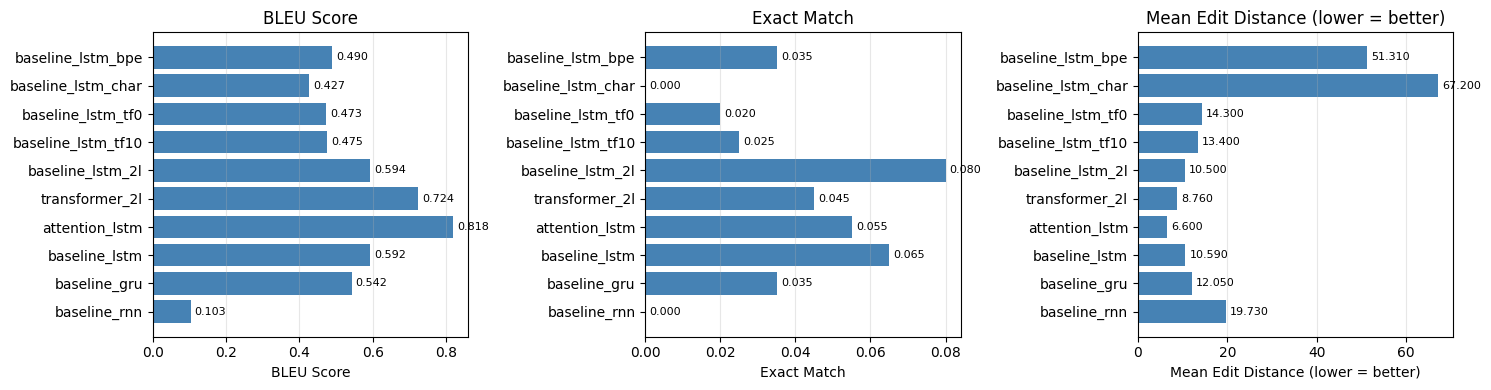

In [ ]:
# BLEU bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, label in zip(
    axes,
    ['bleu', 'exact_match', 'mean_edit_dist'],
    ['BLEU Score', 'Exact Match', 'Mean Edit Distance (lower = better)']
):
    names = [r['name'] for r in ALL_RESULTS]
    values = [r[metric] for r in ALL_RESULTS]
    bars = ax.barh(names, values, color='steelblue')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('results/metrics_comparison_w_bpe.png', dpi=150)
plt.show()

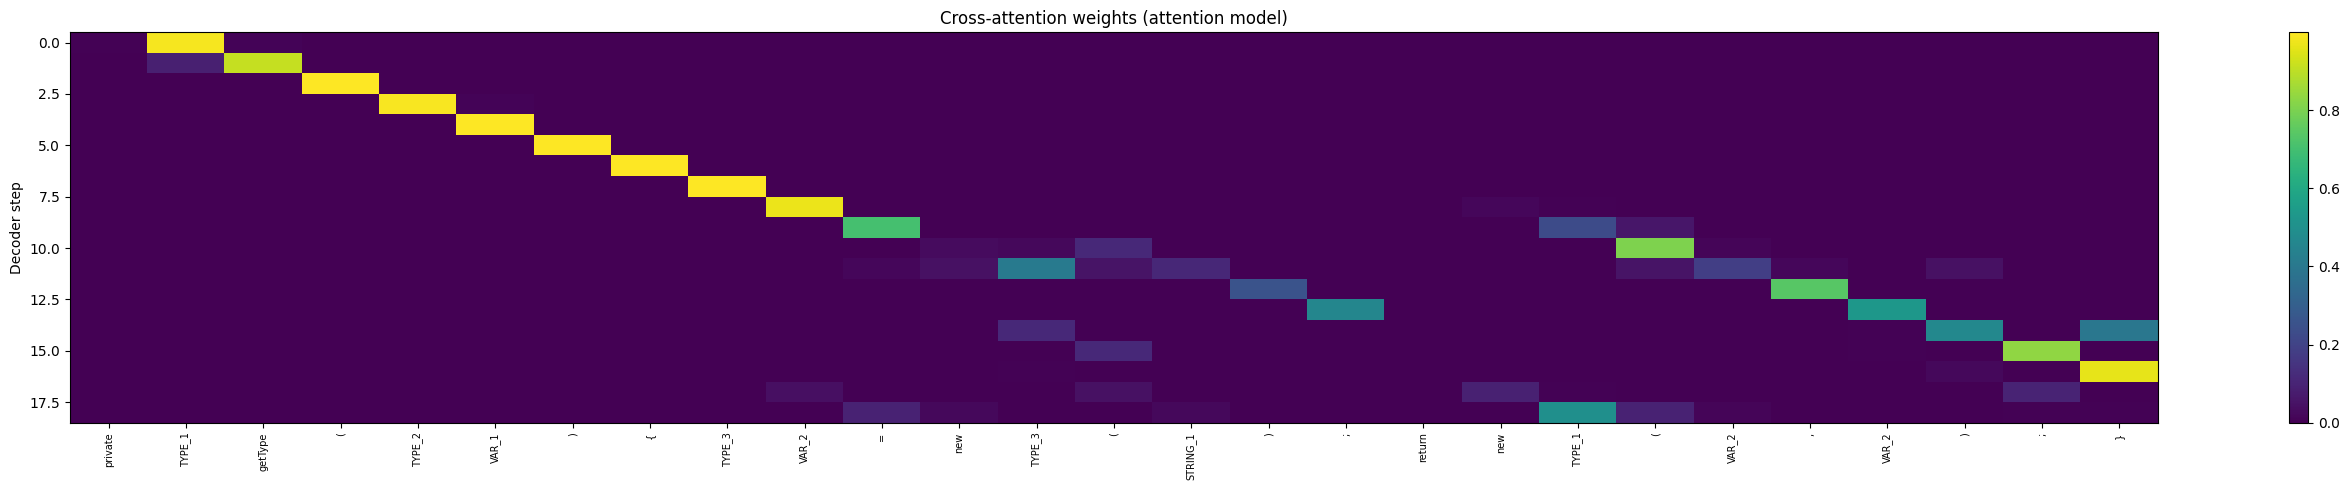

In [ ]:
# Attention heatmap (cross-attention of best attention model)
@torch.no_grad()
def get_attention_weights(model, src_tensor, device):
    model.eval()
    if src_tensor.dim() == 1:
        src_tensor = src_tensor.unsqueeze(0).to(device)
    enc_outputs, hidden = model.encoder(src_tensor)
    input_token = torch.tensor([1], device=device)
    all_weights = []
    for _ in range(40):
        pred, hidden, attn_w = model.decoder(input_token, hidden, enc_outputs)
        all_weights.append(attn_w.squeeze().cpu().numpy())
        next_tok = pred.argmax(dim=-1)
        if next_tok.item() == 2: break
        input_token = next_tok
    return np.array(all_weights)


# loading best attention checkpoint
enc_a = AttnEncoder(V, embed_dim=128, hidden_dim=256, num_layers=1, model='lstm').to(DEVICE)
dec_a = AttnDecoder(V, embed_dim=128, hidden_dim=256, num_layers=1, model='lstm').to(DEVICE)
attn_model = AttnSeq2Seq(enc_a, dec_a, DEVICE).to(DEVICE)
attn_model.load_state_dict(torch.load('checkpoints/attention_lstm_best.pt', map_location=DEVICE))

buggy_sample, fixed_sample = next(iter(test_loader_ws)) # first bach of dataloader (LLM-inspired)
src = buggy_sample[0].to(DEVICE) # first example of batch

src_tokens = vocab_ws.decode([t for t in src.tolist() if t not in (0, 1, 2)])
weights = get_attention_weights(attn_model, src, DEVICE)

fig, ax = plt.subplots(figsize=(min(len(src_tokens), 30), 5))
im = ax.imshow(weights[:, :len(src_tokens)], aspect='auto', cmap='viridis')
ax.set_xticks(range(len(src_tokens)))
ax.set_xticklabels(src_tokens, rotation=90, fontsize=7)
ax.set_ylabel('Decoder step')
ax.set_title('Cross-attention weights (attention model)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('results/attention_heatmap.png', dpi=150)
plt.show()

## 11. Qualitative Examples

In [ ]:
def show_examples(model, loader, vocab, device, n=5, model_name=''):
    model.eval()
    count = 0
    print(f'\n{"-"*70}')
    print(f'Examples from: {model_name}')
    print(f'{"-"*70}')
    for buggy, fixed in loader:
        buggy = buggy.to(device)
        for i in range(buggy.shape[0]):
            if count >= n: return
            src = vocab.decode([t for t in buggy[i].tolist() if t not in (0, 1, 2)])
            ref = vocab.decode([t for t in fixed[i].tolist() if t not in (0, 1, 2)])
            hyp = vocab.decode(model.generate(buggy[i]))
            print(f'BUGGY:     {" ".join(src[:20])}...')
            print(f'PREDICTED: {" ".join(hyp[:20])}...')
            print(f'REFERENCE: {" ".join(ref[:20])}...')
            print(f'MATCH: {"YES" if hyp == ref else "NO"}  |  EditDist: {mean_edit_distance([ref],[hyp]):.1f}')
            print()
            count += 1

# transformer
enc_t  = TfEncoder(V, d_model=128, num_heads=4, num_layers=2, d_ff=256).to(DEVICE)
dec_t  = TfDecoder(V, d_model=128, num_heads=4, num_layers=2, d_ff=256).to(DEVICE)
tf_model = TransformerSeq2Seq(enc_t, dec_t, DEVICE).to(DEVICE)
state_dict = torch.load('checkpoints/transformer_2l_best.pt', map_location=DEVICE)
new_state_dict = {}
for k, v in state_dict.items():
    k = k.replace('encoder.embed.', 'encoder.embedding.')
    k = k.replace('decoder.embed.', 'decoder.embedding.')
    k = k.replace('.ffn.net.', '.ffn.network.')
    new_state_dict[k] = v
tf_model.load_state_dict(new_state_dict)
show_examples(tf_model, test_loader_ws, vocab_ws, DEVICE, n=5, model_name='Transformer')

# attention model
show_examples(attn_model, test_loader_ws, vocab_ws, DEVICE, n=5, model_name='Attention LSTM')


----------------------------------------------------------------------
Examples from: Transformer
----------------------------------------------------------------------
BUGGY:     private TYPE_1 getType ( TYPE_2 VAR_1 ) { TYPE_3 VAR_2 = new TYPE_3 ( STRING_1 ) ; return new TYPE_1...
PREDICTED: private TYPE_1 getType ( TYPE_2 VAR_1 ) { TYPE_3 VAR_2 = new TYPE_3 ( STRING_1 ) ; return new TYPE_1...
REFERENCE: private TYPE_1 getType ( TYPE_2 VAR_1 ) { TYPE_3 VAR_2 = new TYPE_3 ( STRING_1 ) ; return new TYPE_1...
MATCH: NO  |  EditDist: 5.0

BUGGY:     public TYPE_1 METHOD_1 ( ) { TYPE_1 output = VAR_1 [ VAR_2 ] ; if ( ( VAR_2 ) >...
PREDICTED: public TYPE_1 METHOD_1 ( ) { TYPE_1 [ ] VAR_1 = VAR_2 [ ] ; if ( VAR_2 > 0...
REFERENCE: public TYPE_1 METHOD_1 ( ) { TYPE_1 output = VAR_1 [ VAR_2 ] ; if ( ( VAR_2 ) >=...
MATCH: NO  |  EditDist: 15.0

BUGGY:     private void METHOD_1 ( java.lang.Class VAR_1 ) { android.content.Intent intent = new android.content.Intent ( this , VAR_1 ) ; METHOD_2.